# Summary

This notbeook XXX

---
# Setup


In [1]:
# imports

##% imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from popy.io_tools import load_behavior
from popy.behavior_data_tools import add_history_of_feedback, add_switch_info, drop_time_fields
from popy.behavioral_analysis import fit_glm
from popy.plotting.plotting_tools import plot_strategy, plot_glm_weights


---
# Load data

In [2]:
behav = load_behavior()
behav = drop_time_fields(behav)  # drop columns related to event timing
behav

,monkey,session,trial_id,block_id,best_target,target,feedback
0,ka,010720,0,0,2,3.0,1.0
1,ka,010720,1,0,2,3.0,0.0
2,ka,010720,2,0,2,1.0,1.0
3,ka,010720,3,0,2,1.0,0.0
4,ka,010720,4,0,2,3.0,1.0
...,...,...,...,...,...,...,...
39214,po,310822,419,9,2,1.0,0.0
39215,po,310822,420,9,2,1.0,1.0
39216,po,310822,421,9,2,1.0,1.0
39217,po,310822,422,9,2,1.0,1.0


---
# Create figures

## Fig. 1D-E, Performance and shifting curves

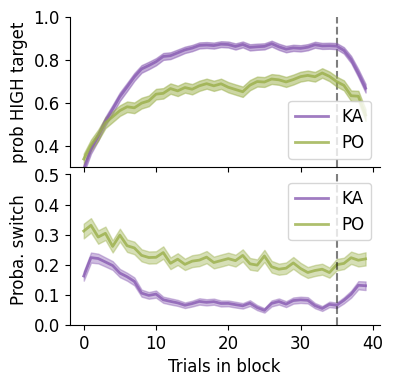

In [3]:
# plot strategy
fig, axs = plot_strategy(behav)

## Fig. 1F, History dependence of switching

In [4]:
behav = add_history_of_feedback(behav, one_column=False, num_trials=10)
behav = add_switch_info(behav)
behav

,monkey,session,trial_id,block_id,best_target,target,feedback,R_1,R_2,R_3,...,T_2,T_3,T_4,T_5,T_6,T_7,T_8,T_9,T_10,switch
0,ka,010720,0,0,2,3.0,1.0,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,ka,010720,1,0,2,3.0,0.0,1.0,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
2,ka,010720,2,0,2,1.0,1.0,0.0,1.0,NaN,...,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0
3,ka,010720,3,0,2,1.0,0.0,1.0,0.0,1.0,...,3.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0
4,ka,010720,4,0,2,3.0,1.0,0.0,1.0,0.0,...,1.0,3.0,3.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
39214,po,310822,419,9,2,1.0,0.0,1.0,1.0,0.0,...,1.0,3.0,1.0,1.0,3.0,1.0,1.0,3.0,1.0,0.0
39215,po,310822,420,9,2,1.0,1.0,0.0,1.0,1.0,...,1.0,1.0,3.0,1.0,1.0,3.0,1.0,1.0,3.0,0.0
39216,po,310822,421,9,2,1.0,1.0,1.0,0.0,1.0,...,1.0,1.0,1.0,3.0,1.0,1.0,3.0,1.0,1.0,0.0
39217,po,310822,422,9,2,1.0,1.0,1.0,1.0,0.0,...,1.0,1.0,1.0,1.0,3.0,1.0,1.0,3.0,1.0,0.0


Permutation 1/500 for monkey ka
Permutation 101/500 for monkey ka
Permutation 201/500 for monkey ka
Permutation 301/500 for monkey ka
Permutation 401/500 for monkey ka
Monkey: ka, CV accuracy: 0.84 +/- 0.01
Permutation 1/500 for monkey po
Permutation 101/500 for monkey po
Permutation 201/500 for monkey po
Permutation 301/500 for monkey po
Permutation 401/500 for monkey po
Monkey: po, CV accuracy: 0.77 +/- 0.03


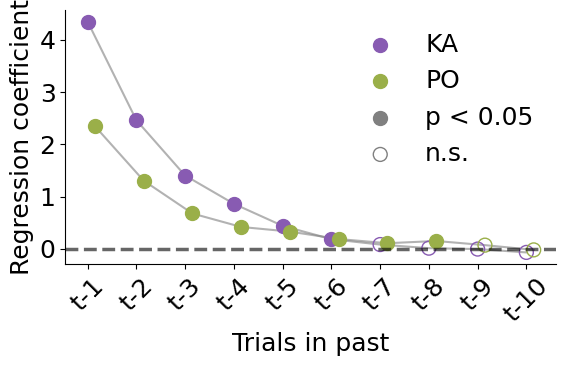

In [5]:
# Fit the GLM
monkeys = ['ka', 'po']
predictors = ['R_1', 'R_2', 'R_3', 'R_4', 'R_5', 'R_6', 'R_7', 'R_8', 'R_9', 'R_10']#, 'trials_since_switch', 'target', 'RT', 'best_target', 'trial_id']
target = 'switch'

behav = behav.dropna(subset=[f'R_{i}' for i in range(1, 11)] + [target])

df_res = fit_glm(behav, target=target, predictors=predictors, n_permutations=500)

plot_glm_weights(df_res)

